# 🍬 Demand Forecasting - Candy Distributor
## Section 3 of 5: Supply Chain & Distribution Analytics

**Role of this notebook in the project:**

| Tool | Responsibility |
|---|---|
| **SQL** | Data cleaning, joins, sales analysis, inventory analysis |
| **Python** *(this notebook)* | Demand forecasting — the one task SQL cannot do |
| **Power BI** | All dashboards, KPIs, and interactive visualisation |

This notebook has one clear job: take 2021–2024 historical sales data, build a demand forecast for each product through 2025, validate it honestly, and export the results for use in SQL and Power BI.

---

### Methodology

**Model:** Linear Regression with trend + seasonality features
- **Trend feature:** integer time index (captures the growth trajectory)
- **Seasonality features:** 12 binary month dummy variables (captures monthly patterns)
- **Train / validate split:** train on 2021–2023, validate on 2024 holdout
- **Final model:** retrain on full 2021–2024 data → forecast Jan–Dec 2025

---

In [2]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error

# Style
PALETTE = ['#2D6A4F','#40916C','#52B788','#74C69D','#95D5B2','#B7E4C7']
ACCENT, WARN, NEUTRAL = '#2D6A4F', '#E76F51', '#6C757D'

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.titleweight': 'bold',
    'axes.titlesize': 12, 'figure.facecolor': 'white'
})
os.makedirs('charts', exist_ok=True)
os.makedirs('data/exports', exist_ok=True)
print('Libraries ready')

Libraries ready


## Step 1 — Load & Prepare Data

In [3]:
# Load Sales Data
sales = pd.read_csv(r'C:\Users\Harsha\Desktop\Supply Chain\Dataset\Candy_Sales.csv')
sales['Order Date'] = pd.to_datetime(sales['Order Date'])
sales['Year']  = sales['Order Date'].dt.year
sales['Month'] = sales['Order Date'].dt.month

# Aggregate to monthly level per product
monthly = (
    sales
    .groupby(['Product Name', 'Year', 'Month'])['Sales']
    .sum()
    .reset_index()
    .sort_values(['Product Name', 'Year', 'Month'])
    .reset_index(drop=True)
)

print(f'Products: {monthly["Product Name"].nunique()}')
print(f'Date range: {sales["Order Date"].min().date()} → {sales["Order Date"].max().date()}')
print(f'Monthly records: {len(monthly)}')
print(f'Avg monthly obs per product: {len(monthly) / monthly["Product Name"].nunique():.0f}') 
print()
print(monthly.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).to_frame('Total Revenue'))

Products: 15
Date range: 2021-01-03 → 2024-12-30
Monthly records: 391
Avg monthly obs per product: 26

                                   Total Revenue
Product Name                                    
Wonka Bar - Triple Dazzle Caramel       28485.00
Wonka Bar -Scrumdiddlyumptious          27874.80
Wonka Bar - Milk Chocolate              26867.75
Wonka Bar - Fudge Mallows               24890.40
Wonka Bar - Nutty Crunch Surprise       23574.95
Lickable Wallpaper                       7860.00
Kazookles                                1205.75
Wonka Gum                                 597.50
Everlasting Gobstopper                    130.00
Fizzy Lifting Drinks                       78.75
Hair Toffee                                76.50
SweeTARTS                                  61.50
Laffy Taffy                                53.73
Nerds                                      15.00
Fun Dip                                    12.00


## Step 2 — Feature Engineering

In [4]:
# Feature Builder 
def build_features(df):
    """
    Two types of features:
      t     : linear time index → captures overall trend direction
      M1-M12: binary month dummies → captures repeating seasonal pattern
    """
    df = df.copy().reset_index(drop=True)
    df['t'] = range(len(df))            # 0, 1, 2 ... n-1
    for m in range(1, 13):
        df[f'M{m}'] = (df['Month'] == m).astype(int)
    return df

FEATURE_COLS = ['t'] + [f'M{m}' for m in range(1, 13)]

# Demo: what features look like for one product
demo = monthly[monthly['Product Name'] == 'Wonka Bar - Milk Chocolate'].copy()
demo = build_features(demo)
print('Feature matrix sample (first 6 rows):')
print(demo[['Year','Month','Sales'] + FEATURE_COLS].head(6).to_string(index=False))

Feature matrix sample (first 6 rows):
 Year  Month  Sales  t  M1  M2  M3  M4  M5  M6  M7  M8  M9  M10  M11  M12
 2021      1 295.75  0   1   0   0   0   0   0   0   0   0    0    0    0
 2021      2 139.75  1   0   1   0   0   0   0   0   0   0    0    0    0
 2021      3 409.50  2   0   0   1   0   0   0   0   0   0    0    0    0
 2021      4 490.75  3   0   0   0   1   0   0   0   0   0    0    0    0
 2021      5 364.00  4   0   0   0   0   1   0   0   0   0    0    0    0
 2021      6 474.50  5   0   0   0   0   0   1   0   0   0    0    0    0


## Step 3 — Train, Validate & Forecast

In [6]:
# Model Training & Forecasting 
forecasts    = []
mape_scores  = {}
mae_scores   = {}
model_store  = {}   # keep models for coefficient inspection

for product in sorted(monthly['Product Name'].unique()):
    pdf   = monthly[monthly['Product Name'] == product].copy()
    pdf   = build_features(pdf)
    train = pdf[pdf['Year'] <= 2023]
    valid = pdf[pdf['Year'] == 2024]

    if len(train) < 12 or len(valid) == 0:
        print(f'Skipped {product} — insufficient data')
        continue

    # --- Validate on 2024 holdout ---
    val_model = LinearRegression()
    val_model.fit(train[FEATURE_COLS], train['Sales'])
    val_preds = val_model.predict(valid[FEATURE_COLS]).clip(min=0)

    mape = mean_absolute_percentage_error(valid['Sales'], val_preds) * 100
    mae  = mean_absolute_error(valid['Sales'], val_preds)
    mape_scores[product] = round(mape, 1)
    mae_scores[product]  = round(mae,  1)

    # --- Retrain on full 2021-2024 data → forecast 2025 ---
    full_model = LinearRegression()
    full_model.fit(pdf[FEATURE_COLS], pdf['Sales'])
    model_store[product] = full_model

    t_start = len(pdf)
    rows = []
    for i, m in enumerate(range(1, 13)):
        row = {'Product Name': product, 'Year': 2025, 'Month': m, 't': t_start + i}
        for mm in range(1, 13):
            row[f'M{mm}'] = int(mm == m)
        rows.append(row)

    fdf = pd.DataFrame(rows)
    fdf['Forecast_Sales']  = full_model.predict(fdf[FEATURE_COLS]).clip(min=0)
    fdf['Forecast_Revenue'] = fdf['Forecast_Sales']   # alias for export
    forecasts.append(fdf[['Product Name', 'Year', 'Month', 'Forecast_Revenue']])

forecast_df = pd.concat(forecasts, ignore_index=True)
print(f'Forecasts generated for {len(mape_scores)} products')
print(f'Total forecast records: {len(forecast_df)}')

# Simple average forecast for low-data products
skipped_products = [
    'Everlasting Gobstopper', 'Fizzy Lifting Drinks', 'Fun Dip',
    'Hair Toffee', 'Laffy Taffy', 'Nerds', 'SweeTARTS'
]

simple_forecasts = []

for product in skipped_products:
    pdf = monthly[monthly['Product Name'] == product].copy()
    
    if len(pdf) == 0:
        continue
    
    # Calculate average monthly sales from all available data
    avg_monthly = pdf['Sales'].mean()
    
    for m in range(1, 13):
        simple_forecasts.append({
            'Product Name'    : product,
            'Year'            : 2025,
            'Month'           : m,
            'Forecast_Revenue': round(avg_monthly, 2)
        })

simple_df = pd.DataFrame(simple_forecasts)
forecast_df = pd.concat([forecast_df, simple_df], ignore_index=True)

print(f'Total forecast records after adding simple forecasts: {len(forecast_df)}')
print(f'Products with forecasts: {forecast_df["Product Name"].nunique()}')

Skipped Everlasting Gobstopper — insufficient data
Skipped Fizzy Lifting Drinks — insufficient data
Skipped Fun Dip — insufficient data
Skipped Hair Toffee — insufficient data
Skipped Laffy Taffy — insufficient data
Skipped Nerds — insufficient data
Skipped SweeTARTS — insufficient data
Forecasts generated for 8 products
Total forecast records: 96
Total forecast records after adding simple forecasts: 180
Products with forecasts: 15


## Step 4 — Validation Results (2024 Holdout)

2024 Holdout Validation — MAPE & MAE by Product
MAPE < 20% is generally acceptable for monthly demand forecasting
[WARN]  Kazookles                                   MAPE:  81.9%  MAE: $  18.6
[WARN]  Lickable Wallpaper                          MAPE:  58.0%  MAE: $ 153.4
[GOOD]  Wonka Bar - Fudge Mallows                   MAPE:  16.5%  MAE: $ 113.0
[WARN]  Wonka Bar - Milk Chocolate                  MAPE:  22.5%  MAE: $ 169.2
[GOOD]  Wonka Bar - Nutty Crunch Surprise           MAPE:  16.5%  MAE: $ 109.8
[GOOD]  Wonka Bar - Triple Dazzle Caramel           MAPE:  19.3%  MAE: $ 158.4
[GOOD]  Wonka Bar -Scrumdiddlyumptious              MAPE:  19.8%  MAE: $ 159.4
[WARN]  Wonka Gum                                   MAPE:  55.0%  MAE: $   8.7

Average MAPE across all products: 36.2%


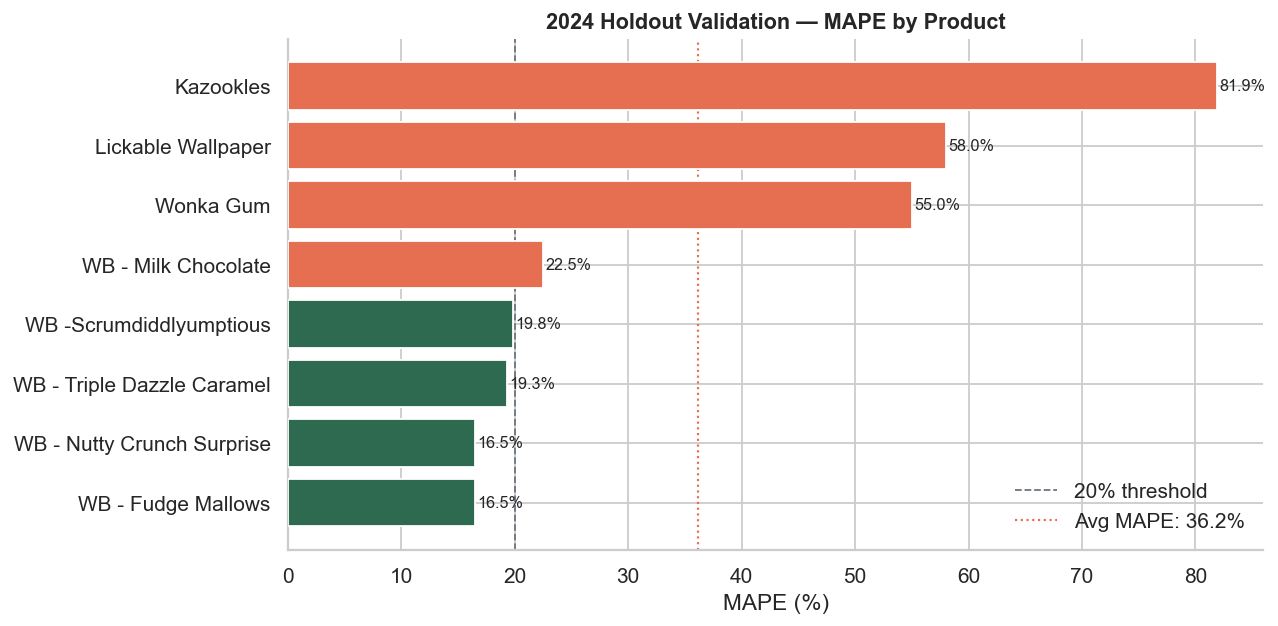

In [7]:
#  Validation Report 
print('2024 Holdout Validation — MAPE & MAE by Product')
print('MAPE < 20% is generally acceptable for monthly demand forecasting')
print('=' * 62)

results = []
for product in sorted(mape_scores):
    flag = 'GOOD' if mape_scores[product] < 20 else 'WARN'
    results.append({
        'Product': product,
        'MAPE %': mape_scores[product],
        'MAE ($)': mae_scores[product],
        'Flag': flag
    })
    print(f'[{flag}]  {product:<42}  MAPE: {mape_scores[product]:>5.1f}%  MAE: ${mae_scores[product]:>6.1f}')

avg_mape = np.mean(list(mape_scores.values()))
print(f'\nAverage MAPE across all products: {avg_mape:.1f}%')

# Validation bar chart
val_df = pd.DataFrame(results).sort_values('MAPE %')
short  = lambda n: n.replace('Wonka Bar - ','WB - ').replace('Wonka Bar -','WB -')
val_df['Short'] = val_df['Product'].apply(short)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [ACCENT if m < 20 else WARN for m in val_df['MAPE %']]
ax.barh(val_df['Short'], val_df['MAPE %'], color=colors, zorder=3)
ax.axvline(20, color=NEUTRAL, linestyle='--', linewidth=1, label='20% threshold')
ax.axvline(avg_mape, color=WARN, linestyle=':', linewidth=1.2, label=f'Avg MAPE: {avg_mape:.1f}%')
for i, m in enumerate(val_df['MAPE %']):
    ax.text(m + 0.2, i, f'{m:.1f}%', va='center', fontsize=9)
ax.set_title('2024 Holdout Validation — MAPE by Product')
ax.set_xlabel('MAPE (%)')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('charts/validation_mape.png', bbox_inches='tight')
plt.show()

## Step 5 — Forecast Visualisation

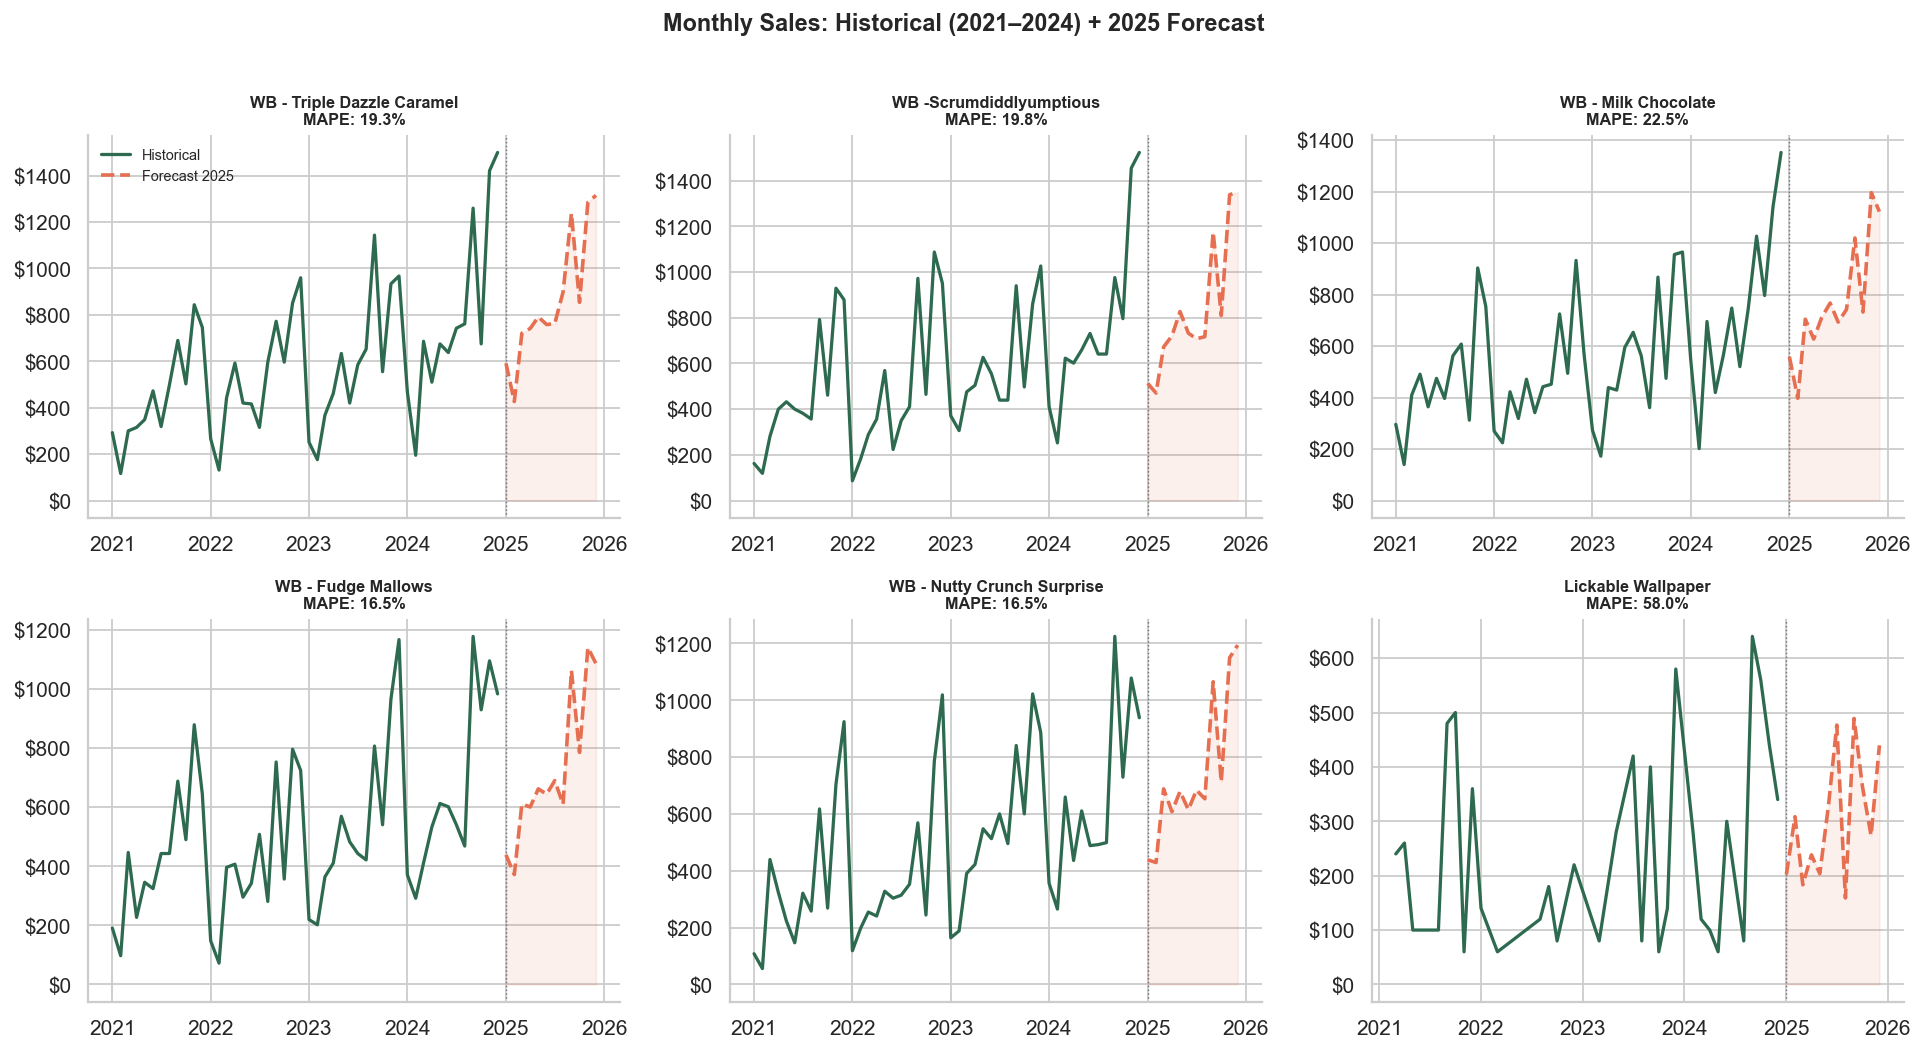

In [8]:
#  Plot Historical + Forecast for Top 6 Products 
top6 = sales.groupby('Product Name')['Sales'].sum().nlargest(6).index.tolist()
short = lambda n: n.replace('Wonka Bar - ','WB - ').replace('Wonka Bar -','WB -')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, product in enumerate(top6):
    ax   = axes[idx]
    hist = monthly[monthly['Product Name'] == product].copy()
    hist['date'] = pd.to_datetime(hist[['Year','Month']].assign(day=1))
    fore = forecast_df[forecast_df['Product Name'] == product].copy()
    fore['date'] = pd.to_datetime(fore[['Year','Month']].assign(day=1))

    ax.plot(hist['date'], hist['Sales'],
            color=ACCENT, linewidth=1.8, label='Historical', zorder=3)
    ax.plot(fore['date'], fore['Forecast_Revenue'],
            color=WARN, linewidth=2, linestyle='--', label='Forecast 2025', zorder=3)
    ax.axvline(pd.Timestamp('2025-01-01'), color=NEUTRAL, linewidth=0.8, linestyle=':')
    ax.fill_between(fore['date'], fore['Forecast_Revenue'], alpha=0.1, color=WARN)

    mape_val = mape_scores.get(product)
    ax.set_title(f'{short(product)}\nMAPE: {mape_val:.1f}%', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}'))
    if idx == 0:
        ax.legend(frameon=False, fontsize=8)

plt.suptitle('Monthly Sales: Historical (2021–2024) + 2025 Forecast',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('charts/forecast_all_products.png', bbox_inches='tight')
plt.show()

## Step 6 — Annual Forecast Summary

2024 Actual Revenue : $46,968
2025 Forecast Total : $52,833
Projected Growth    : +12.5%

                     Product Name  Forecast_Revenue_2025  Rank
Wonka Bar - Triple Dazzle Caramel           10383.750000     1
   Wonka Bar -Scrumdiddlyumptious           10029.600000     2
       Wonka Bar - Milk Chocolate            9270.625000     3
Wonka Bar - Nutty Crunch Surprise            8918.695000     4
        Wonka Bar - Fudge Mallows            8695.800000     5
               Lickable Wallpaper            3666.521933     6
           Everlasting Gobstopper             519.960000     7
                        Kazookles             457.409848     8
                      Hair Toffee             229.440000     9
                        Wonka Gum             209.759936    10
             Fizzy Lifting Drinks             189.000000    11
                        SweeTARTS              73.800000    12
                          Fun Dip              72.000000    13
                      Laffy 

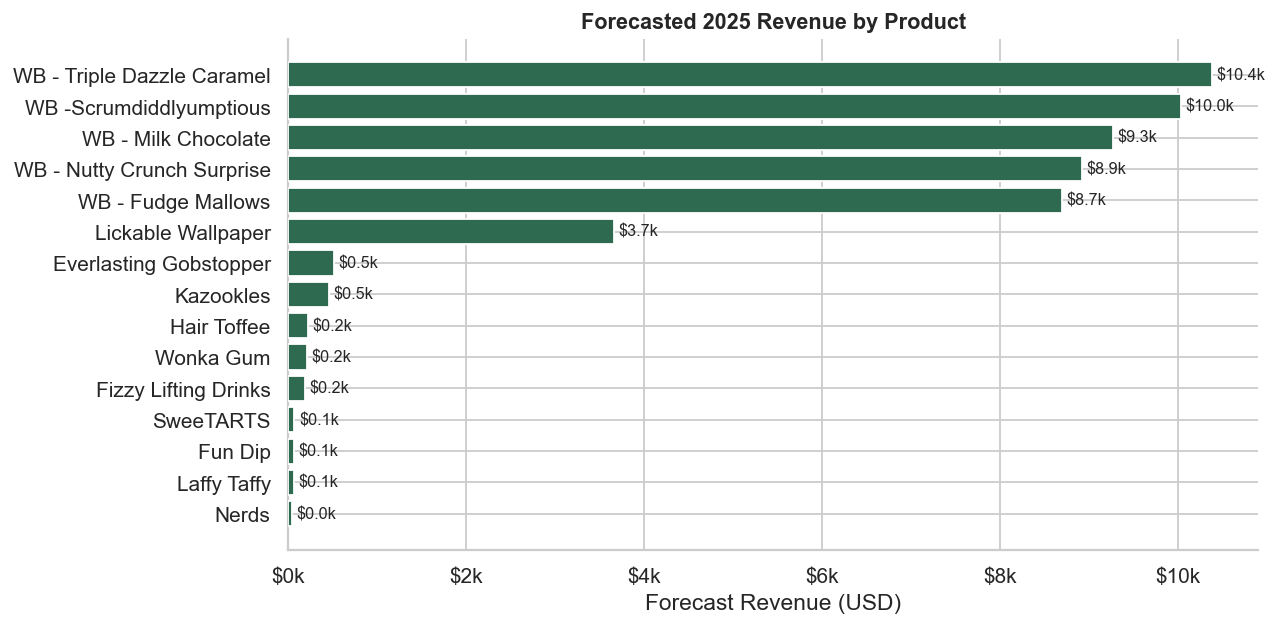

In [13]:
#  Annual Forecast by Product 
annual = forecast_df.groupby('Product Name')['Forecast_Revenue'].sum().reset_index()
annual.columns = ['Product Name', 'Forecast_Revenue_2025']
annual = annual.sort_values('Forecast_Revenue_2025', ascending=False).reset_index(drop=True)
annual['Rank'] = annual.index + 1
total_2024 = sales[sales['Year'] == 2024]['Sales'].sum()
total_2025 = annual['Forecast_Revenue_2025'].sum()

print(f'2024 Actual Revenue : ${total_2024:,.0f}')
print(f'2025 Forecast Total : ${total_2025:,.0f}')
print(f'Projected Growth    : {(total_2025/total_2024-1)*100:+.1f}%')
print()
print(annual.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
short_names = [short(p) for p in annual['Product Name']]
ax.barh(short_names[::-1], annual['Forecast_Revenue_2025'][::-1], color=PALETTE[0], zorder=3)
ax.set_title('Forecasted 2025 Revenue by Product')
ax.set_xlabel('Forecast Revenue (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
for i, v in enumerate(annual['Forecast_Revenue_2025'][::-1]):
    ax.text(v + 50, i, f'${v/1000:.1f}k', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('charts/forecast_annual_summary.png', bbox_inches='tight')
plt.show()

## Step 7 — Export Forecast for SQL & Power BI

In [18]:
#  Export 1: Full monthly forecast (for Power BI) 
export_monthly = forecast_df.rename(columns={
    'Product Name'    : 'product',
    'Year'            : 'forecast_year',
    'Month'           : 'forecast_month',
    'Forecast_Revenue': 'forecast_revenue'
})

# Approximate units using average unit price from historical data
# Load products to get unit price
products_df = pd.read_csv(r'C:\Users\Harsha\Desktop\Supply Chain\Dataset\Candy_Products.csv')

# Calculate average unit price directly from sales
avg_price = (
    sales.groupby('Product Name')
         .apply(lambda x: x['Sales'].sum() / x['Units'].sum())
         .reset_index()
)
avg_price.columns = ['product', 'avg_unit_price']

export_monthly = export_monthly.merge(avg_price, on='product', how='left')
export_monthly['forecast_units'] = (
    export_monthly['forecast_revenue'] / export_monthly['avg_unit_price']
).round(0).astype(int)

# Primary export for SQL 4.6 (inventory coverage query)
export_monthly[['product','forecast_month','forecast_units']].to_csv(
    'data/exports/forecast_2025.csv', index=False
)

# Full export for Power BI
export_monthly.drop(columns=['avg_unit_price']).to_csv(
    'data/exports/forecast_2025_full.csv', index=False
)

#  Export 2: MAPE scores (for Power BI tooltip / table) 
pd.DataFrame({
    'product': list(mape_scores.keys()),
    'mape_pct': list(mape_scores.values()),
    'mae_usd': [mae_scores[p] for p in mape_scores.keys()]
}).to_csv('data/exports/forecast_validation.csv', index=False)

print('Exports complete:')
print('  data/exports/forecast_2025.csv         → load into SQL (file 05)')
print('  data/exports/forecast_2025_full.csv    → import into Power BI')
print('  data/exports/forecast_validation.csv   → MAPE scores for Power BI')
print()
print('Monthly forecast sample:')
print(export_monthly.head(10).to_string(index=False))

Exports complete:
  data/exports/forecast_2025.csv         → load into SQL (file 05)
  data/exports/forecast_2025_full.csv    → import into Power BI
  data/exports/forecast_validation.csv   → MAPE scores for Power BI

Monthly forecast sample:
  product  forecast_year  forecast_month  forecast_revenue  avg_unit_price  forecast_units
Kazookles           2025               1         26.631005            3.25               8
Kazookles           2025               2         28.263481            3.25               9
Kazookles           2025               3         61.097304            3.25              19
Kazookles           2025               4         32.756250            3.25              10
Kazookles           2025               5         37.631250            3.25              12
Kazookles           2025               6         23.818750            3.25               7
Kazookles           2025               7         33.568750            3.25              10
Kazookles           2025     